# ===================================================
# 1. PROJECT OVERVIEW
# ===================================================


Business Problem:
Airlines and travel platforms need to estimate ticket prices 
based on route, airline, booking timing, and travel season.

ML Objective:
Build a supervised regression model to predict Total Fare (BDT).

Target Variable:

- Total Fare (BDT)

Evaluation Metrics:
- R²
- MAE
- RMSE

# ============================================================
# 2. DATA LOADING & INITIAL INSPECTION
# ============================================================

### Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from pathlib import Path

### Load CSV

In [4]:
csv_file_path = Path('raw_bangladesh_data\Flight_Price_Dataset_of_Bangladesh.csv')
df = pd.read_csv(csv_file_path)


<>:1: SyntaxWarning: invalid escape sequence '\F'
<>:1: SyntaxWarning: invalid escape sequence '\F'
C:\Users\MelchizedekTettehNar\AppData\Local\Temp\ipykernel_728\3494232636.py:1: SyntaxWarning: invalid escape sequence '\F'
  csv_file_path = Path('raw_bangladesh_data\Flight_Price_Dataset_of_Bangladesh.csv')


### Basic Inspection

In [5]:
df.head()


,Airline,Source,Source Name,Destination,Destination Name,Departure Date & Time,Arrival Date & Time,Duration (hrs),Stopovers,Aircraft Type,Class,Booking Source,Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Seasonality,Days Before Departure
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17 06:25:00,2025-11-17 07:38:10,1.219526,Direct,Airbus A320,Economy,Online Website,21131.225021,5169.683753,26300.908775,Regular,10
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16 00:17:00,2025-03-16 00:53:31,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.395471,200.000000,11805.395471,Regular,14
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13 12:03:00,2025-12-13 14:44:22,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.499349,11982.374902,51864.874251,Winter Holidays,83
3,Singapore Airlines,RJH,"Shah Makhdum Airport, Rajshahi",DAC,"Hazrat Shahjalal International Airport, Dhaka",2025-05-30 03:21:00,2025-05-30 04:02:09,0.686054,Direct,Airbus A320,Economy,Direct Booking,4435.607340,200.000000,4635.607340,Regular,56
4,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,2025-04-25 09:14:00,2025-04-25 23:17:20,14.055609,1 Stop,Airbus A350,Business,Direct Booking,59243.806146,14886.570922,74130.377068,Regular,90


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 57000 entries, 0 to 56999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Airline                57000 non-null  str    
 1   Source                 57000 non-null  str    
 2   Source Name            57000 non-null  str    
 3   Destination            57000 non-null  str    
 4   Destination Name       57000 non-null  str    
 5   Departure Date & Time  57000 non-null  str    
 6   Arrival Date & Time    57000 non-null  str    
 7   Duration (hrs)         57000 non-null  float64
 8   Stopovers              57000 non-null  str    
 9   Aircraft Type          57000 non-null  str    
 10  Class                  57000 non-null  str    
 11  Booking Source         57000 non-null  str    
 12  Base Fare (BDT)        57000 non-null  float64
 13  Tax & Surcharge (BDT)  57000 non-null  float64
 14  Total Fare (BDT)       57000 non-null  float64
 15  Seasonality  

In [7]:
df.describe()

,Duration (hrs),Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Days Before Departure
count,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000
mean,3.994955,58899.556573,11448.238494,71030.316199,45.460579
std,4.094043,68840.614499,12124.344329,81769.199536,26.015657
min,0.500000,1600.975688,200.000000,1800.975688,1.000000
25%,1.003745,8856.316983,200.000000,9602.699787,23.000000
50%,2.644656,31615.996792,9450.940481,41307.544990,45.000000
75%,5.490104,85722.930389,17513.046160,103800.906963,68.000000
max,15.831719,449222.933770,73383.440066,558987.332444,90.000000


### ============================================================
# 3. DATA CLEANING & VALIDATION
### ============================================================

#### Drop Irrelevant Columns

In [8]:
# COPY THE DATAFRAME
flight_df = df.copy()

# Drop irrelevant columns
flight_df.drop(columns=["Source Name", "Destination Name"], inplace=True)

# Convert datetime columns
flight_df["Departure Date & Time"] = pd.to_datetime(flight_df["Departure Date & Time"])
flight_df["Arrival Date & Time"] = pd.to_datetime(flight_df["Arrival Date & Time"])

# Check for negative fares
flight_df = flight_df[flight_df["Total Fare (BDT)"] >= 0]

# Drop leakage columns (VERY IMPORTANT)
flight_df.drop(columns=["Base Fare (BDT)", "Tax & Surcharge (BDT)"], inplace=True)

### ============================================================
# 4. FEATURE ENGINEERING
### ============================================================

In [9]:
# Extract time features
flight_df["Month"] = flight_df["Departure Date & Time"].dt.month
flight_df["Day"] = flight_df["Departure Date & Time"].dt.day
flight_df["Weekday"] = flight_df["Departure Date & Time"].dt.weekday
flight_df["Hour"] = flight_df["Departure Date & Time"].dt.hour
flight_df["Is_Weekend"] = flight_df["Weekday"].isin([5,6]).astype(int)

# Encode stopovers
flight_df["Stopovers"] = flight_df["Stopovers"].replace({
    "Direct": 0,
    "1 Stop": 1,
    "2 Stop": 2
})

# Drop original datetime columns
flight_df.drop(columns=["Departure Date & Time", "Arrival Date & Time"], inplace=True)

# One-Hot Encode categorical variables
flight_df = pd.get_dummies(flight_df, drop_first=True)


In [10]:
flight_df['Total Fare (BDT)'].min()

np.float64(1800.9756881504618)

### ============================================================
# 5. EXPLORATORY DATA ANALYSIS (EDA)
### ============================================================

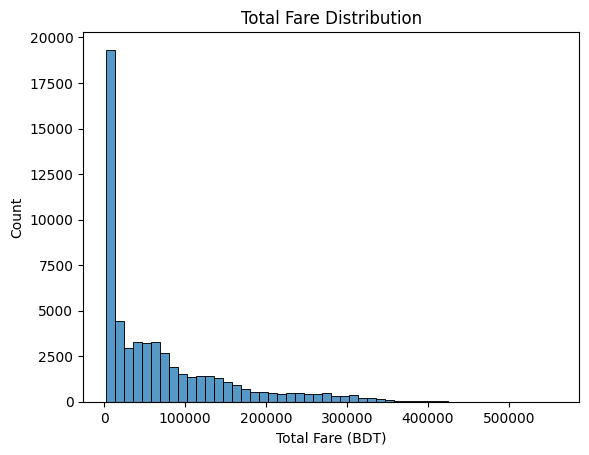

In [11]:
# Distribution of Total Fare
plt.figure()
sns.histplot(flight_df["Total Fare (BDT)"], bins=50)
plt.title("Total Fare Distribution")
plt.show()

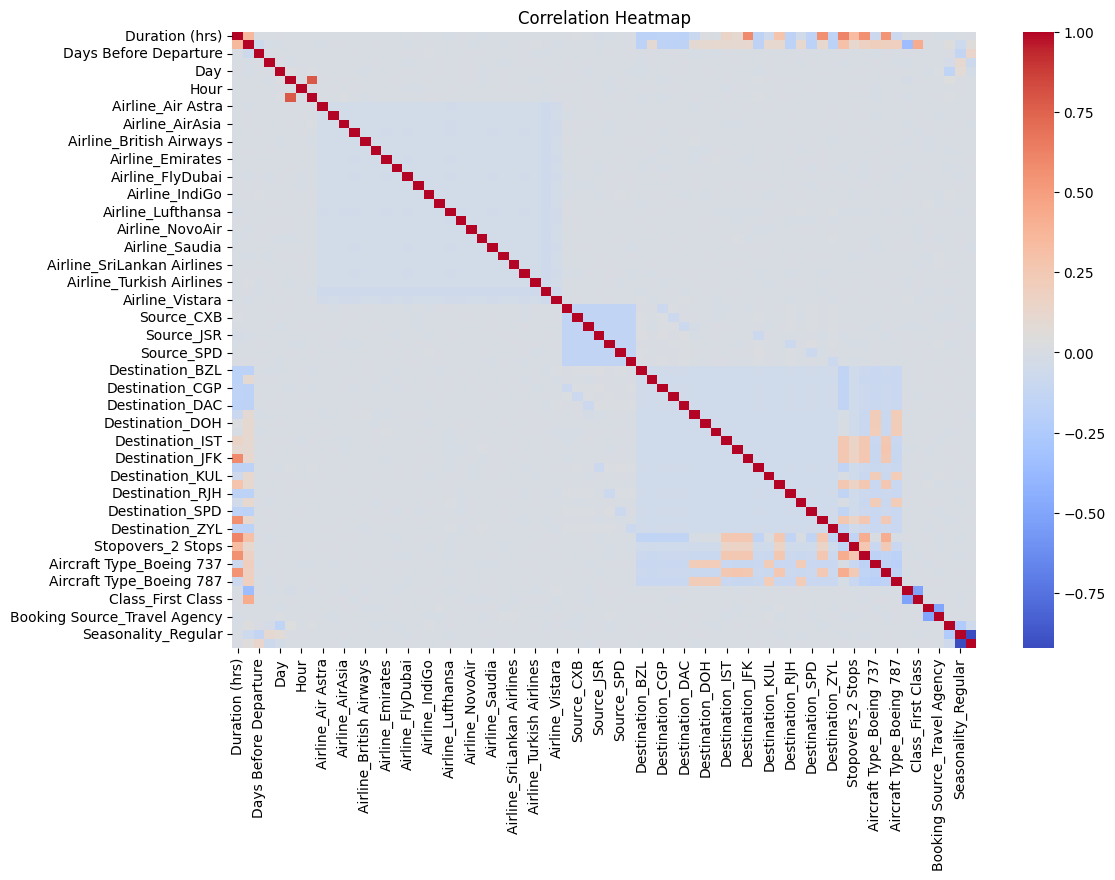

In [12]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(flight_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### ============================================================
# 6. TRAIN-TEST SPLIT
### ============================================================

In [13]:
X = flight_df.drop("Total Fare (BDT)", axis=1)
y = flight_df["Total Fare (BDT)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale (for linear models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### ============================================================
# 7. BASELINE MODEL – LINEAR REGRESSION
### ============================================================

In [14]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression Results")
print("R2:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression Results
R2: 0.5699857731055924
MAE: 40680.068993569344
RMSE: 53540.8210391767


### ============================================================
# 8. ADVANCED MODELS
### ============================================================

In [15]:
# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

# Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))


Random Forest R2: 0.6641718750665868


### ============================================================
# 9. MODEL COMPARISON
### ============================================================

In [16]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Random Forest"],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_rf)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ]
})

results

,Model,R2,MAE,RMSE
0,Linear Regression,0.569986,40680.068994,53540.821039
1,Ridge,0.569986,40679.722594,53540.806239
2,Random Forest,0.664172,28256.145635,47315.359793


### ============================================================
# 10. FEATURE IMPORTANCE (RANDOM FOREST)
### ============================================================


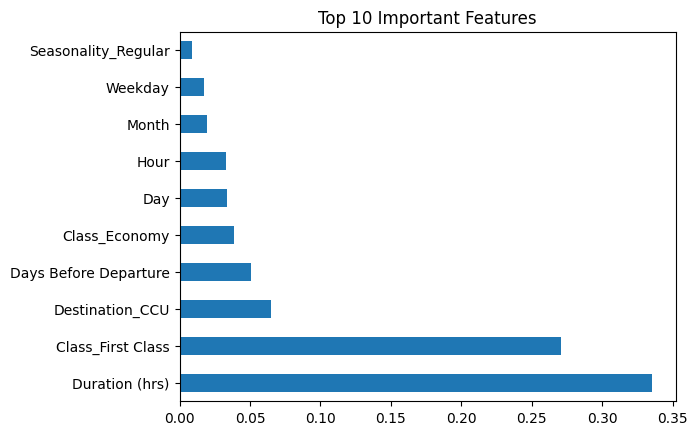

In [17]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Top 10 Important Features")
plt.show()